---
---

# Evaluation and Inference

**START HERE** if you only want to load a pre-trained model and run inference.

Run the cell below to load a saved model without executing training cells.

### Dual Workflow Support

This notebook supports two workflows:

1. **Full Training**: Run all cells from top to bottom
2. **Inference Only**: Run only the entry point cell below, then continue with evaluation

Both workflows result in properly configured `model` and `datahandler` variables.

In [1]:
# ============================================================
# EVALUATION-ONLY ENTRY POINT
# ============================================================
# Run this cell to load a model and prepare for inference
# without running any training cells above.

import torch
from src.models import load_checkpoint_full
from src.datahandler import DataHandler
from src.robot import Robot
from src.normrange import NormRange

checkpoint_path = 'checkpoints/calm-river-2.pt'
checkpoint_data = load_checkpoint_full(checkpoint_path,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

model = checkpoint_data['model']
model.eval()  # Set to inference mode

# Extract metadata
robot_config = checkpoint_data['robot_config']
training_info = checkpoint_data['training_info']

# Reconstruct datahandler from checkpoint metadata
robot_name = robot_config.get('name', 'youbot')
datahandler = DataHandler(robot=Robot(robot=robot_name))

# Restore normalization bounds from model buffers
if model.norm_initialized:
    datahandler.set_normalization_bounds(model.get_normalization_bounds())

device = next(model.parameters()).device
print(f"Loaded model from: {checkpoint_path}")
print(f"Robot: {robot_name}")
print(f"Device: {device}")
print(f"Normalization initialized: {model.norm_initialized}")
print(f"\nTraining info:")
for key, value in training_info.items():
    print(f"  {key}: {value}")

Loaded model from: checkpoints/calm-river-2.pt
Robot: YouBot
Device: cuda:0
Normalization initialized: True

Training info:
  epoch: 288
  val_loss: 0.1690365792931737
  train_loss: 0.17212071192675624
  samples: 3000000


Now we want to check whether our network also works on new data. To do this, we generate some data again. The generated TCPs serve as input to our model. Via the <code>__call__</code> function, we can propagate our data through the network to get an output. What was not mentioned before is that the data was normalized before being fed into the network. This normalization must be reversed before we can continue working with the data.

### Test Data Generation and Inference

The cell below generates fresh test data, runs inference through the model, and denormalizes the outputs back to radians:

1. **Disable extreme positions** — test data should be purely random to reflect real-world distribution
2. **Forward pass** — normalized TCP is fed through the model to get predicted joint angles
3. **Denormalize** — both ground truth and predictions are converted from normalized space back to radians
4. **Sanity check** — verifies that `norm → denorm` round-trips produce identical values

### Evaluation Metrics

The metrics module (`src.metrics`) computes two categories of error:

- **Joint-space metrics** — MAE and RMSE measure angular error in radians/degrees for each joint. Percentiles (P50, P95, P99) reveal worst-case behavior. Success rate gives the fraction of samples where *all* joints are within 1° or 5° of ground truth.
- **TCP-space metrics** — Position error is the Euclidean distance between where the end-effector actually is vs where it should be, which is the most practically meaningful metric. Orientation error measures rotational deviation via geodesic angle. Success rates report the fraction of samples within 1mm or 5mm.

In [2]:
datahandler.compute_extreme_positions = False
datahandler.set_torch(True)
model.eval()
tcp, gt_joints = datahandler(20000)
pred = model(tcp)
# Denormalize joint positions and TCP and get it off the GPU and back to numpy arrays
gt_pos = datahandler.denorm_joint(gt_joints).cpu().numpy()
pred = datahandler.denorm_joint(pred).cpu().detach().numpy()
datahandler.set_torch(False)

# Sanity Check — works in standard, relative, and noised modes
import numpy as np

if datahandler.relative or datahandler.noised:
    t, j, _, _ = datahandler(20, normalize=False, concat=False)  # (tcp, jpos, ntcp, njpos)
else:
    t, j = datahandler(20, normalize=False)

t_norm   = datahandler.norm_tcp(t)
t_denorm = datahandler.denorm_tcp(t_norm)
j_norm   = datahandler.norm_joint(j)
j_denorm = datahandler.denorm_joint(j_norm)

print("Normalization works:",
      np.all(np.isclose(j, j_denorm)) and np.all(np.isclose(t, t_denorm)))

Normalization works: True


In [3]:
from src.metrics import compute_all_metrics, format_metrics

metrics = compute_all_metrics(gt_pos, pred, robot=datahandler.robot)
print(format_metrics(metrics))

--- Joint-Space Metrics ---
MAE Total:  0.708570 rad  (40.60 deg)
RMSE Total: 0.994262 rad  (56.97 deg)
Success Rate: <1deg 0.1%  |  <5deg 16.1%

Joint    MAE(deg)  Max(deg)  P50(deg)  P95(deg)  P99(deg)
---------------------------------------------------------
  1         50.36    168.96     55.50    112.72    139.30
  2         21.24    117.51     13.66     63.49     78.29
  3         51.82    242.46     42.55    132.73    161.04
  4         29.19    164.27     18.57     85.80    106.85
  5         50.38    164.62     55.56    112.90    139.00

--- TCP-Space Metrics ---
Position Error:  mean 244.88 mm  |  median 167.62 mm  |  max 817.06 mm
                 P95 689.66 mm  |  P99 764.85 mm
Orientation Error: mean 67.93 deg  |  max 180.00 deg
Success Rate: <1mm 0.0%  |  <5mm 2.2%


## Visualization

We can now display the robot positions for *Ground Truth* and *Prediction* of the joint angle positions for individual values. Using `RobotViewer`, you can show multiple configurations with distinct colors and labels.

- **Orange** represents the *Ground Truth*
- **Green** represents the *Prediction*

This gives us a graphical representation of what our network has learned.

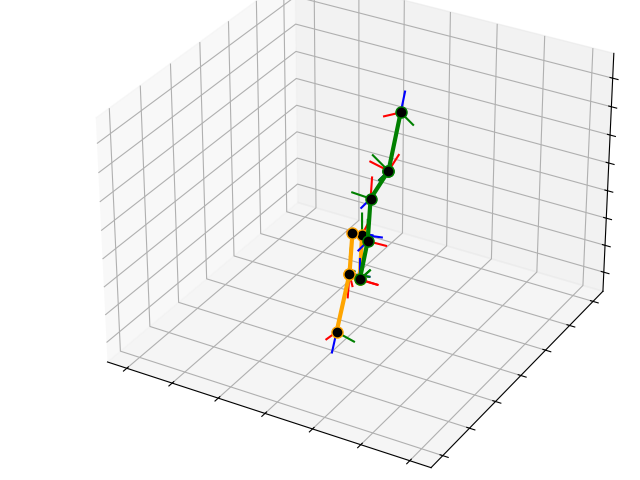

In [4]:
%matplotlib widget
from src.robot_animation import RobotViewer

viewer = RobotViewer(datahandler.robot)
# Sample index to visualize
k = 103
viewer.draw(
    [gt_pos[k], pred[k]], 
    colors=['orange', 'green'], 
    labels=['Ground Truth', 'Prediction']
)

### Trajectory Selection

To evaluate how well the network predicts joint angles for a sequence of TCP positions, we generate trajectories using the `src.trajectories` module.

**Available trajectories:**
| Name | Description | Joints Affected |
|------|-------------|-----------------|
| `circle` | Sweep joint 1 from max to min | Joint 1 only |
| `wave` | Sinusoidal motion with phase offset | All joints |
| `reach` | Extend arm outward then retract | Joints 2-3 |
| `spiral` | Combined rotation + reach | Joints 1 + 2-3 |
| `random_smooth` | Random waypoints with cubic interpolation | All joints |
| `figure_eight` | Figure-8 pattern in joint space | Joints 1-2 |
| `square` | Square pattern with sharp 90° corners | Joints 1-2 |
| `pringles` | True pringles with 90° phase shift | Joints 1-2 |

Change `trajectory_type` in the cell below to try different trajectories.

In [10]:
from src.trajectories import list_trajectories, get_trajectory

# List available trajectories
print("Available trajectories:", list_trajectories())

# Select trajectory type
trajectory_type = "pringles"  # Change this to try different trajectories
n_frames = 60

# Generate trajectory (returns radians)
arr = get_trajectory(
    name=trajectory_type,
    robot=datahandler.robot,
    n_frames=n_frames,
)

print(f"\nGenerated '{trajectory_type}' trajectory: {arr.shape}")

Available trajectories: ['circle', 'wave', 'reach', 'spiral', 'random_smooth', 'figure_eight', 'square', 'pringles']

Generated 'pringles' trajectory: (60, 5)


The generated joint angle vector can be passed to `TrajectoryAnimator` to display an animated trajectory with matplotlib. The animator supports:
- Multiple trajectories with different colors
- Optional TCP trail visualization
- Legend display for comparing trajectories

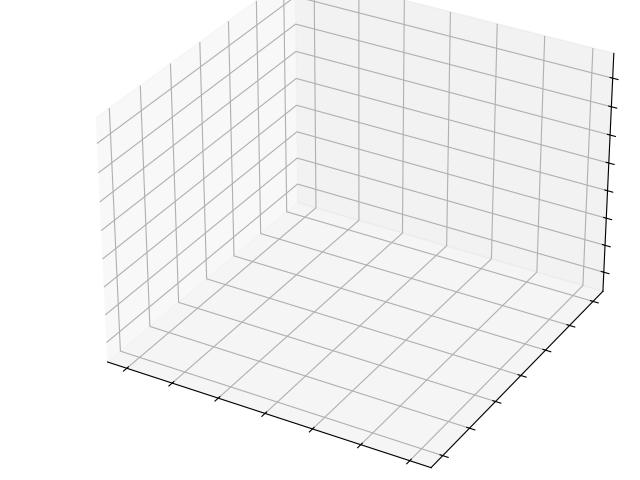

In [11]:
%matplotlib widget
from src.robot_animation import TrajectoryAnimator

animator = TrajectoryAnimator(robot=datahandler.robot)
animator.add_trajectory(arr, color='orange', label='Ground Truth', show_trail=True)
animator.animate(interval=100, repeat=False, show_legend=False)

### Trajectory Inference Loop

The cell below runs frame-by-frame inference on the generated trajectory:

1. **FK computation** — converts ground-truth joint angles to TCP frames via forward kinematics
2. **Normalization** — TCP frames are normalized to match the model's expected input range
3. **Frame-by-frame prediction** — each normalized TCP is fed through the model individually, producing predicted joint angles
4. **Mode handling** — in standard mode (non-relative, non-noised), only the TCP is used as input; in relative/noised mode, the previous joint position and both old and new TCP are concatenated as input
5. **Denormalization** — each predicted output is converted back to radians and appended to the trajectory array

In [12]:
datahandler.set_torch(False)

# Raw (unnormalized) target TCPs — needed to compute deltas in raw coordinates,
# matching how training data is constructed in DataHandler.generate_data().
arr_tcp_raw  = datahandler.get_tcp(arr)            # (n, 6) or (n, 12) — euler-dependent
arr_tcp_norm = datahandler.norm_tcp(arr_tcp_raw)   # used by the standard / noised-only branches

# Initial state: ground-truth start
old_jpos_rad  = np.array([arr[0]])                       # (1, num_joints) radians
old_jpos_norm = datahandler.norm_joint(old_jpos_rad)[0]  # (num_joints,)

trajectory = []
for i in range(len(arr)):
    target_tcp_raw = arr_tcp_raw[i:i+1]            # (1, T) absolute target TCP

    if not datahandler.relative and not datahandler.noised:
        # Standard mode: feed the normalized target TCP.
        in_np = arr_tcp_norm[i:i+1]                # (1, T)
    else:
        # Concatenated mode: [jpos | norm(FK(jpos)) | third_slot].
        # FK(jpos) keeps (jpos, tcp) consistent with the training invariant.
        current_tcp_raw  = datahandler.get_tcp(old_jpos_rad)         # (1, T)
        current_tcp_norm = datahandler.norm_tcp(current_tcp_raw)[0]  # (T,)

        if datahandler.relative:
            # Training applies `tcp_end = tcp_end - tcp` (datahandler.py:276),
            # so the third slot must be the normalized delta.
            delta_raw  = target_tcp_raw - current_tcp_raw
            third_norm = datahandler.norm_tcp(delta_raw)[0]          # (T,)
        else:
            # Noised-only (relative=False, noised=True): no subtract in training,
            # so the third slot is the normalized target TCP itself.
            third_norm = arr_tcp_norm[i]                             # (T,)

        in_np = np.concatenate((old_jpos_norm, current_tcp_norm, third_norm))[None, :]

    in_ = torch.tensor(in_np, dtype=torch.float32, device=device)
    output_norm = model(in_).cpu().detach().numpy()      # (1, num_joints)
    output_rad  = datahandler.denorm_joint(output_norm)  # (1, num_joints)

    trajectory.append(output_rad[0])

    # Feed the prediction back as the next "current" state.
    old_jpos_norm = output_norm[0]
    old_jpos_rad  = output_rad

trajectory = np.asarray(trajectory)                      # (n, num_joints)

Finally, we can animate the predicted joint angle positions and compare them visually to the ground truth trajectory. Using `TrajectoryAnimator`, we can display both trajectories simultaneously with different colors.

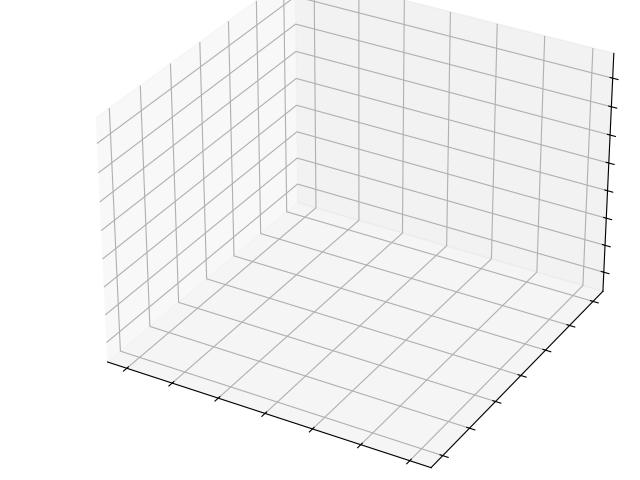

In [13]:
%matplotlib widget
from src.robot_animation import TrajectoryAnimator

# Compare ground truth vs prediction trajectories side-by-side
animator2 = TrajectoryAnimator(robot=datahandler.robot)
animator2.add_trajectory(arr, color='orange', label='Ground Truth', show_trail=True)
animator2.add_trajectory(trajectory, color='green', label='Prediction', show_trail=True)
animator2.animate(interval=100, repeat=False, show_legend=True)